# Matar los 60 Hz sin dañar el QRS

La interferencia de red parece el ruido más fácil de eliminar: está concentrada en una
frecuencia conocida, así que basta un filtro rechaza-banda centrado ahí. En la práctica
hay dos formas de equivocarse, y son opuestas entre sí.

Este notebook mide ambas y muestra dónde está el punto útil.

**Requisitos:** `numpy`, `scipy`, `matplotlib`.

In [1]:
import numpy as np
from scipy import signal as sg
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 10, 'figure.dpi': 120, 'axes.grid': True,
                     'grid.alpha': 0.25, 'axes.spines.top': False,
                     'axes.spines.right': False})

FS = 500
TINTA, ROJO, VERDE, AZUL, NARANJA = '#333', '#c0392b', '#0b6e5f', '#2c5f8a', '#b8730a'

## 1. De dónde sale la interferencia

El cuerpo y el cableado eléctrico del edificio forman, sin proponérselo, un condensador.
El cableado está a unos cientos de voltios respecto a tierra y oscila a la frecuencia de
la red; ese campo induce una corriente muy pequeña en el cuerpo, que el amplificador del
ECG recoge junto con la señal cardiaca. Se llama acoplo capacitivo.

La frecuencia depende de dónde estés: **60 Hz en México y Norteamérica, 50 Hz en Europa
y buena parte de Asia**. Es lo primero que hay que verificar antes de copiar código de
un tutorial extranjero.

Además del fundamental suelen aparecer armónicos en 120 y 180 Hz, porque las cargas no
lineales conectadas a la red (fuentes conmutadas, iluminación LED, motores) deforman la
onda.

In [2]:
def ecg_sintetico(fs=FS, dur=20.0, hr=62.0, amp_r=1.30, hrv=0.045, semilla=7):
    """ECG sintético por suma de gaussianas, con variabilidad natural del RR."""
    rng = np.random.default_rng(semilla)
    n = int(fs*dur); t = np.arange(n)/fs; x = np.zeros(n)
    ondas = [(-0.200, 0.15, 0.025), (-0.035,-0.10, 0.008), (0.0, 1.10, 0.010),
             ( 0.035,-0.25, 0.010), ( 0.280, 0.30, 0.045)]
    rr_medio = 60.0/hr; tr = 0.4; picos = []
    while tr < dur - 0.5:
        picos.append(tr)
        for c, a, s in ondas:
            x += a*np.exp(-0.5*((t-(tr+c))/s)**2)
        tr += max(0.35, rng.normal(rr_medio, hrv))
    return t, x*(amp_r/1.10), np.array(picos)


def red(t, amp=0.12, f0=60.0):
    """Interferencia de red: fundamental y armónicos. f0=50.0 en Europa."""
    return (amp*np.sin(2*np.pi*f0*t) + 0.28*amp*np.sin(2*np.pi*2*f0*t + 0.7)
            + 0.16*amp*np.sin(2*np.pi*3*f0*t + 1.9))


t, limpio, picos = ecg_sintetico()
P = picos[1:-1]                      # descartar latidos de borde
contaminado = limpio + red(t)
print(f'{len(P)} latidos analizables')

19 latidos analizables


## 2. El filtro notch y su factor Q

Un notch (rechaza-banda) atenúa una banda angosta alrededor de una frecuencia central.
Su parámetro clave es el **factor Q**, que fija el ancho de esa banda:

$$
\text{ancho}_{-3\,\text{dB}} = \frac{f_0}{Q}
$$

Con $f_0 = 60$ Hz, un Q de 2 da un ancho de 30 Hz; un Q de 200, de 0.3 Hz.

La intuición sugiere que más estrecho es mejor: se quita solo lo que estorba. Vamos a
ver que esa intuición tiene un límite duro.

Como en los artículos anteriores, todo el filtrado se hace con `filtfilt` para no
introducir desfase.

In [3]:
def notch(x, f0, Q, fs=FS):
    """Filtro rechaza-banda de fase cero centrado en f0."""
    b, a = sg.iirnotch(f0, Q, fs=fs)
    return sg.filtfilt(b, a, x)


def error_rms(y, ref, picos, t0=-0.05, t1=0.05, fs=FS):
    """Error RMS respecto a la referencia, en ventanas alrededor del pico R (µV)."""
    e = []
    for tr in picos:
        i0, i1 = int((tr+t0)*fs), int((tr+t1)*fs)
        e.append(y[i0:i1] - ref[i0:i1])
    return np.sqrt(np.mean(np.concatenate(e)**2)) * 1000

## 3. Primer error: un notch demasiado ancho

Aquí se aísla el fundamental de 60 Hz para medir solo el efecto de Q.

In [4]:
solo_60 = limpio + 0.12*np.sin(2*np.pi*60*t)

print(f'{"Q":>5} {"ancho":>10} | {"error en el QRS":>16}')
print('-' * 36)
for Q in (1, 2, 5, 10, 20, 50):
    y = notch(solo_60, 60, Q)
    print(f'{Q:>5} {60/Q:>7.2f} Hz | {error_rms(y, limpio, P):>13.1f} µV')

print(f'\nSin filtrar: {error_rms(solo_60, limpio, P):.1f} µV')

    Q      ancho |  error en el QRS
------------------------------------
    1   60.00 Hz |          44.0 µV
    2   30.00 Hz |          13.4 µV
    5   12.00 Hz |           2.5 µV
   10    6.00 Hz |           0.7 µV
   20    3.00 Hz |           0.2 µV
   50    1.20 Hz |           0.1 µV

Sin filtrar: 84.9 µV


Con Q = 1 el filtro introduce 44 µV de error. Suena poco frente a los 85 µV de la
interferencia original, pero el problema no es el promedio: es **dónde** ocurre.

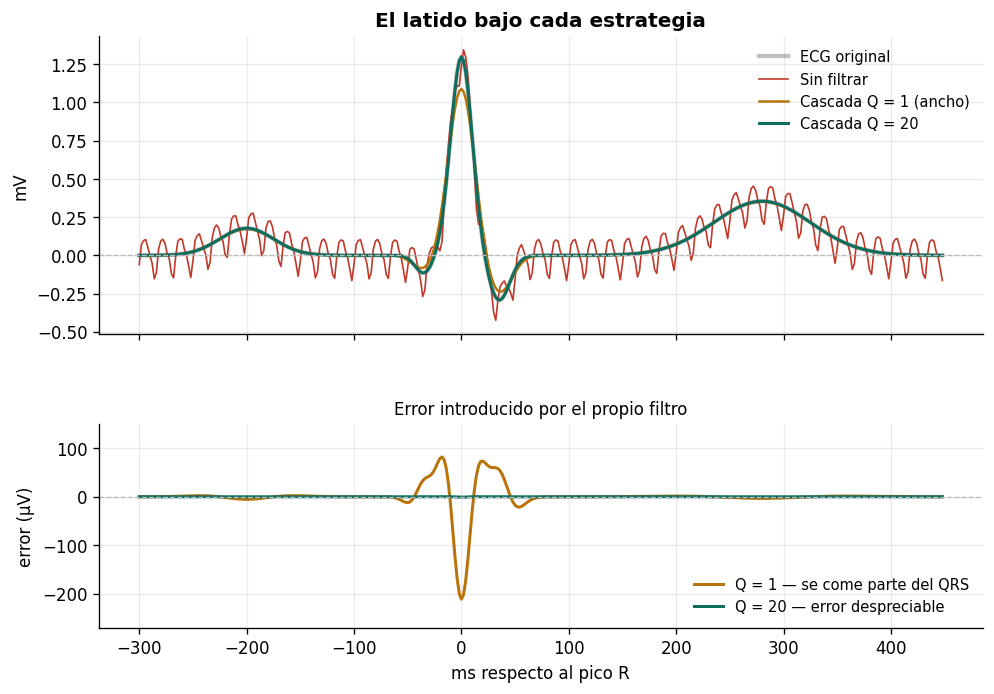

Amplitud del pico R original: 1299 µV
Amplitud con Q = 1:           1088 µV
Pérdida: 16.3%


In [5]:
ancho  = notch(notch(notch(contaminado, 60, 1),  120, 1),  180, 1)
casc   = notch(notch(notch(contaminado, 60, 20), 120, 20), 180, 20)

tr = P[3]
i0, i1 = int((tr-0.30)*FS), int((tr+0.45)*FS)
tt = (t[i0:i1] - tr) * 1000

fig, (a1, a2) = plt.subplots(2, 1, figsize=(9.5, 6.4),
                             gridspec_kw={'height_ratios': [1.9, 1.3], 'hspace': 0.36})
a1.plot(tt, limpio[i0:i1], color=TINTA, lw=2.6, alpha=0.30, label='ECG original', zorder=1)
a1.plot(tt, contaminado[i0:i1], color=ROJO, lw=1.0, label='Sin filtrar')
a1.plot(tt, ancho[i0:i1], color=NARANJA, lw=1.5, label='Cascada Q = 1 (ancho)')
a1.plot(tt, casc[i0:i1], color=VERDE, lw=1.8, label='Cascada Q = 20')
a1.axhline(0, color='#bbb', lw=0.8, ls='--'); a1.set_ylabel('mV')
a1.legend(loc='upper right', frameon=False, fontsize=8.8); a1.set_xticklabels([])
a1.set_title('El latido bajo cada estrategia', fontweight='bold')

a2.plot(tt, 1000*(ancho[i0:i1]-limpio[i0:i1]), color=NARANJA, lw=1.8,
        label='Q = 1 — se come parte del QRS')
a2.plot(tt, 1000*(casc[i0:i1]-limpio[i0:i1]), color=VERDE, lw=1.8,
        label='Q = 20 — error despreciable')
a2.axhline(0, color='#bbb', lw=0.8, ls='--')
a2.set_ylim(-270, 150); a2.set_xlabel('ms respecto al pico R'); a2.set_ylabel('error (µV)')
a2.set_title('Error introducido por el propio filtro', fontsize=10)
a2.legend(loc='lower right', frameon=False, fontsize=8.8)
plt.show()

i = int(P[3]*FS)
r_orig = limpio[i-20:i+20].max()
r_ancho = ancho[i-20:i+20].max()
print(f'Amplitud del pico R original: {r_orig*1000:.0f} µV')
print(f'Amplitud con Q = 1:           {r_ancho*1000:.0f} µV')
print(f'Pérdida: {100*(1-r_ancho/r_orig):.1f}%')

El error se concentra exactamente en el complejo QRS y llega a 200 µV, con una pérdida
del 16% en la amplitud del pico R.

La razón es que **el QRS es un evento de banda ancha**. Dura unos 80 ms y sube muy
rápido, así que su energía se reparte por decenas de hercios, incluidos los 60. Un notch
ancho no distingue entre la senoide de la red y esa parte legítima del latido: se lleva
las dos.

Una pérdida del 16% en la R no es cosmética. Los algoritmos de detección de picos usan
umbrales de amplitud, y la relación entre amplitudes de distintas derivaciones es un
criterio diagnóstico.

## 4. Segundo error: un notch demasiado estrecho

Si estrecho fuera mejor, la solución sería subir Q hasta que el filtro toque solo los
60 Hz exactos. El problema es que **la red no está en 60.00 Hz**.

La frecuencia del sistema eléctrico fluctúa continuamente con el balance entre generación
y demanda. En México, la banda de operación normal del Sistema Eléctrico Nacional va de
59.8 a 60.2 Hz, y la tolerancia formal de CFE es de ±0.8%, es decir hasta ±0.48 Hz.

Un notch de Q = 200 tiene un ancho de 0.3 Hz. No cubre ni la banda normal.

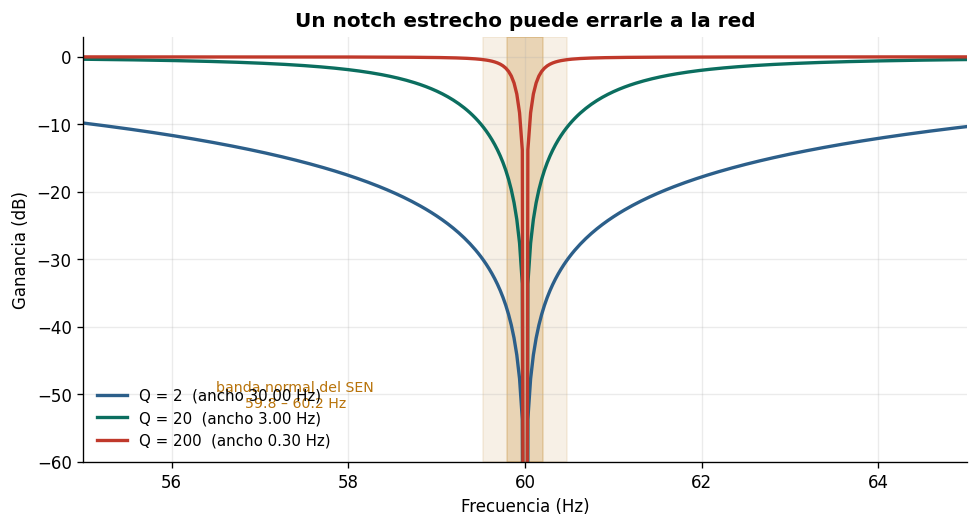

In [6]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.axvspan(59.8, 60.2, color=NARANJA, alpha=0.22)
ax.axvspan(59.52, 60.48, color=NARANJA, alpha=0.10)
for Q, c in [(2, AZUL), (20, VERDE), (200, ROJO)]:
    b, a = sg.iirnotch(60, Q, fs=FS)
    w, h = sg.freqz(b, a, worN=8000, fs=FS)
    ax.plot(w, 20*np.log10(np.abs(h)+1e-12), color=c, lw=2,
            label=f'Q = {Q}  (ancho {60/Q:.2f} Hz)')
ax.set_xlim(55, 65); ax.set_ylim(-60, 3)
ax.set_xlabel('Frecuencia (Hz)'); ax.set_ylabel('Ganancia (dB)')
ax.set_title('Un notch estrecho puede errarle a la red', fontweight='bold')
ax.legend(loc='lower left', frameon=False, fontsize=9)
ax.text(57.4, -52, 'banda normal del SEN\n59.8 – 60.2 Hz', ha='center',
        fontsize=8.5, color=NARANJA)
plt.show()

In [7]:
def remanente(Q, desviacion):
    """Amplitud de interferencia que sobrevive al filtro, en µV.

    El notch se centra en 60.00 Hz, pero la red está en 60 + desviacion.
    """
    f_real = 60 + desviacion
    x = limpio + 0.12*np.sin(2*np.pi*f_real*t)
    y = notch(x, 60, Q)
    return 2*np.abs(np.mean(y * np.exp(-2j*np.pi*f_real*t))) * 1000


print('Amplitud original de la interferencia: 120 µV\n')
print(f'{"Q":>5} {"ancho":>9} |' + ''.join(f'{f"+{d} Hz":>9}' for d in (0.0, 0.2, 0.5, 1.0)))
print('-' * 51)
for Q in (5, 10, 20, 50, 100, 200):
    fila = f'{Q:>5} {60/Q:>6.2f} Hz |'
    for d in (0.0, 0.2, 0.5, 1.0):
        fila += f'{remanente(Q, d):>9.1f}'
    print(fila)

Amplitud original de la interferencia: 120 µV

    Q     ancho |  +0.0 Hz  +0.2 Hz  +0.5 Hz  +1.0 Hz
---------------------------------------------------
    5  12.00 Hz |      0.1      0.2      0.9      3.3
   10   6.00 Hz |      0.2      0.7      3.4     12.0
   20   3.00 Hz |      0.4      2.4     12.2     36.6
   50   1.20 Hz |      0.8     12.5     48.8     87.6
  100   0.60 Hz |      1.6     36.7     87.3    109.6
  200   0.30 Hz |      3.2     75.0    109.4    117.1


Con Q = 200 y la red a 60.5 Hz sobreviven 109 de los 120 µV originales: el filtro
prácticamente no hizo nada, mientras el código parecía correcto y no daba ningún error.

Este es el modo de fallo más traicionero de los dos, porque es silencioso.

## 5. El punto útil

Poniendo las dos curvas juntas, el compromiso se ve de un vistazo.

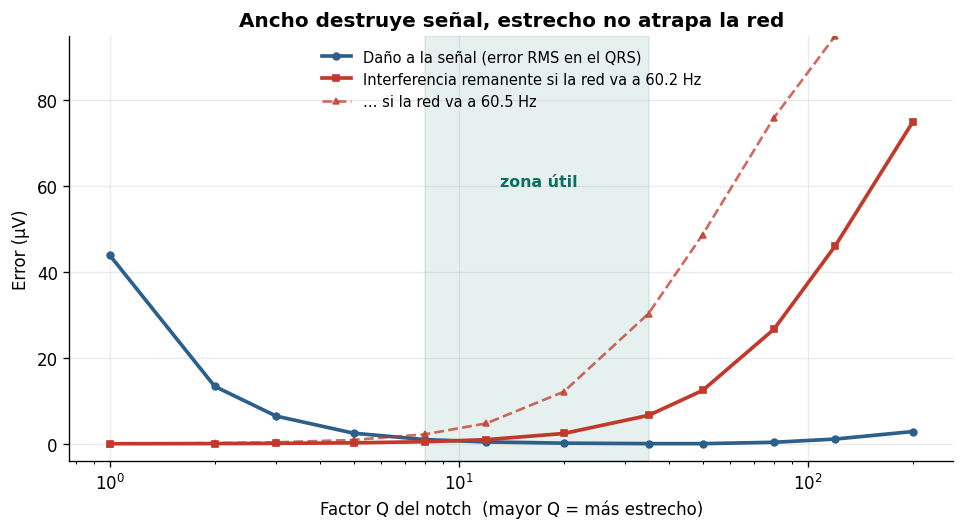

In [8]:
Qs = np.array([1, 2, 3, 5, 8, 12, 20, 35, 50, 80, 120, 200])
dano  = [error_rms(notch(solo_60, 60, Q), limpio, P) for Q in Qs]
rem02 = [remanente(Q, 0.2) for Q in Qs]
rem05 = [remanente(Q, 0.5) for Q in Qs]

fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.semilogx(Qs, dano, color=AZUL, lw=2.2, marker='o', ms=4,
            label='Daño a la señal (error RMS en el QRS)')
ax.semilogx(Qs, rem02, color=ROJO, lw=2.2, marker='s', ms=4,
            label='Interferencia remanente si la red va a 60.2 Hz')
ax.semilogx(Qs, rem05, color=ROJO, lw=1.6, ls='--', marker='^', ms=4, alpha=0.75,
            label='… si la red va a 60.5 Hz')
ax.axvspan(8, 35, color=VERDE, alpha=0.10)
ax.text(17, 60, 'zona útil', ha='center', color=VERDE, fontsize=9.5, fontweight='bold')
ax.set_xlabel('Factor Q del notch  (mayor Q = más estrecho)')
ax.set_ylabel('Error (µV)')
ax.set_title('Ancho destruye señal, estrecho no atrapa la red', fontweight='bold')
ax.legend(loc='upper center', frameon=False, fontsize=8.8)
ax.set_ylim(-4, 95)
plt.show()

Las dos curvas se cruzan. Por debajo de Q ≈ 8 domina el daño al QRS; por encima de
Q ≈ 35 domina el fallo de rechazo. **Entre 10 y 30 ambos errores están por debajo de
5 µV**, y esa es la respuesta práctica: un Q de 20 es una elección defendible en casi
cualquier situación.

Conviene notar que el borde derecho de esa zona no es una constante universal: depende
de cuánto se desvíe la red donde estés midiendo. Si trabajas con equipo alimentado por
una planta de emergencia o un inversor, la desviación puede ser mucho mayor y la zona
útil se corre hacia la izquierda.

## 6. Los armónicos

Un notch en 60 Hz no toca los armónicos. Hay que encadenar uno por cada uno.

In [9]:
def cascada(x, Q=20, armonicos=(60, 120, 180)):
    """Aplica un notch por cada armónico de la red."""
    for f0 in armonicos:
        x = notch(x, f0, Q)
    return x


def potencia(y, lo, hi):
    f, Pw = sg.welch(y, fs=FS, nperseg=4096, noverlap=2048)
    m = (f > lo) & (f < hi)
    return np.trapezoid(Pw[m], f[m])


bajo40 = sg.sosfiltfilt(sg.butter(4, 40, 'low', fs=FS, output='sos'), contaminado)

print(f'{"método":>32} | {"60 Hz":>9} | {"120 Hz":>9} | {"180 Hz":>9} | {"err QRS":>8}')
print('-' * 80)
for nombre, y in [('sin filtrar', contaminado),
                  ('notch solo en 60 Hz (Q=20)', notch(contaminado, 60, 20)),
                  ('cascada 60/120/180 (Q=20)', cascada(contaminado)),
                  ('paso-bajo 40 Hz (Butterworth 4)', bajo40)]:
    print(f'{nombre:>32} | {potencia(y,55,65):>9.2e} | {potencia(y,115,125):>9.2e} | '
          f'{potencia(y,175,185):>9.2e} | {error_rms(y, limpio, P):>5.1f} µV')

                          método |     60 Hz |    120 Hz |    180 Hz |  err QRS
--------------------------------------------------------------------------------
                     sin filtrar |  7.20e-03 |  5.64e-04 |  1.84e-04 |  89.2 µV
      notch solo en 60 Hz (Q=20) |  1.64e-09 |  5.64e-04 |  1.84e-04 |  27.3 µV
       cascada 60/120/180 (Q=20) |  1.63e-09 |  1.15e-13 |  7.78e-15 |   0.2 µV
 paso-bajo 40 Hz (Butterworth 4) |  6.62e-06 |  5.51e-13 |  3.83e-19 |  14.0 µV


La cascada deja un error de 0.2 µV: prácticamente recupera la señal original.

La última fila responde a una pregunta razonable: si los armónicos están en 120 y 180 Hz,
y el 99.9% de la energía del ECG está por debajo de 40 Hz, ¿por qué no un simple
paso-bajo a 40 Hz y listo?

Elimina los armónicos, sí, pero introduce 14 µV de error propio — setenta veces más que
la cascada. Ese es el precio de recortar el contenido legítimo del QRS por encima de
40 Hz. El paso-bajo tiene su lugar en la cadena (contra el EMG), pero no es un sustituto
del notch.

### Una nota sobre `iircomb`

SciPy tiene un filtro de peine que atenúa una frecuencia y todos sus armónicos de una
sola vez. Es más elegante que la cascada, pero tiene una restricción que no siempre se
menciona.

In [10]:
for fs in (360, 480, 500, 600, 1000):
    try:
        sg.iircomb(60, 20, fs=fs, ftype='notch')
        print(f'  fs = {fs:>5} Hz → funciona   (fs/60 = {fs/60:g})')
    except ValueError as err:
        print(f'  fs = {fs:>5} Hz → {err}')

  fs =   360 Hz → funciona   (fs/60 = 6)
  fs =   480 Hz → funciona   (fs/60 = 8)
  fs =   500 Hz → fs must be divisible by w0.
  fs =   600 Hz → funciona   (fs/60 = 10)
  fs =  1000 Hz → fs must be divisible by w0.


`iircomb` exige que la frecuencia de muestreo sea múltiplo entero de la frecuencia a
eliminar. Con 500 Hz y 60 Hz no se puede; con 360, 480 o 600 sí. Si tu registro está a
500 Hz —lo habitual en ECG diagnóstico— la cascada de notches es el camino.

## 7. La función resultante

In [11]:
def quitar_red(x, fs, f_red=60.0, Q=20, n_armonicos=3):
    """Elimina la interferencia de red y sus armónicos mediante notches en cascada.

    f_red: 60.0 en América, 50.0 en Europa y buena parte de Asia.
    Q=20 da un ancho de 3 Hz alrededor de cada armónico: suficiente para absorber
    la fluctuación normal de la red sin llevarse contenido del QRS.

    Solo se filtran armónicos por debajo de Nyquist.
    """
    for k in range(1, n_armonicos + 1):
        f0 = f_red * k
        if f0 >= fs/2:
            break
        b, a = sg.iirnotch(f0, Q, fs=fs)
        x = sg.filtfilt(b, a, x)
    return x


limpiado = quitar_red(contaminado, FS)
print(f'Error RMS tras el filtrado: {error_rms(limpiado, limpio, P):.2f} µV')

Error RMS tras el filtrado: 0.22 µV


El guardia contra Nyquist no es decorativo. A 360 Hz de muestreo, el tercer armónico
(180 Hz) cae justo en el límite y `iirnotch` produce un filtro degenerado.

## Dónde falla esto

**El notch supone que la interferencia es estacionaria.** Si la red se desplaza a lo
largo del registro, o si alguien enciende un equipo a mitad de la grabación, un notch
fijo no sigue el cambio. Para eso existen los **filtros adaptativos** (LMS con referencia
de red) y los métodos de **sustracción**, que estiman amplitud y fase de la senoide latido
a latido y la restan. Son mejores, y también más frágiles cuando la estimación falla.

**La mejor solución no es un filtro.** La interferencia de red es un problema de
instalación: electrodos con buen contacto, cables trenzados y cortos, el paciente lejos
del cableado, y sobre todo un buen rechazo de modo común en el amplificador. Un ECG bien
adquirido casi no necesita notch. Filtrar es reparar algo que no debió pasar.

**Q = 20 no es un número mágico.** Sale de la banda de fluctuación de la red mexicana. En
una instalación con generador propio o inversor, mide primero la frecuencia real antes de
fijar el filtro.

## Referencias

- Kligfield P. et al. *Recommendations for the Standardization and Interpretation of the
  Electrocardiogram, Part I.* Circulation, 2007.
- Levkov C. et al. *Removal of power-line interference from the ECG: a review of the
  subtraction procedure.* BioMedical Engineering OnLine, 2005.
- CFE. *Guía L0000-70: Calidad de la energía — características y límites.*